# dupOri cutter: bistability, switching, and memory

Two incompatible plasmids — **A** (green) and **B** (red) — share a cell,
each replicating logistically against a common copy-number capacity of 30.
Each plasmid encodes a nuclease that degrades the other:

- **X** (encoded by A, amplified by inducer **u1**) cuts **B**
- **Y** (encoded by B, amplified by inducer **u2**) cuts **A**

At basal levels the nucleases are inactive (no inducer → no X or Y), so
whichever plasmid type holds an advantage after an induction event keeps
it indefinitely — **bistability**. Adding u1 tips the system to A-dominant;
removing u1 leaves it there (**memory**). Adding u2 then flips it toward
B-dominance; removing u2 locks that in too.

This notebook drives the switch through a full induction cycle —
**equilibrate → +u1 (A-dominant) → no inducer (memory) → +u2 (B-dominant)
→ no inducer (memory)** — in both a deterministic (ODE) and a stochastic
(Gillespie SSA) single cell, then animates a small growing colony through
the same cycle.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, ReactionNetwork, Simulation, visualize
from multicellular.core.reactions import Reaction

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100

## 1. The dupOri cutter reaction network

Logistic replication competes A and B for shared copy-number capacity
(A + B ≤ 30). Hill-Langmuir production of nucleases X and Y is amplified
by inducers u1 and u2 respectively — at basal levels (no inducer) neither
nuclease accumulates meaningfully. Cross-cutting by X (cuts B) and Y
(cuts A), with rapid nuclease self-degradation to prevent basal buildup,
creates the bistable plasmid switch.

In [2]:
# Plasmid replication: logistic with shared copy-number capacity (30 total)
replication_A = Reaction(
    reactants={"A": 1, "B": 1}, products={"A": 2, "B": 1},
    rate_law_type="custom", rate_params={"alpha": 50},
    custom_rate_law=lambda rc, pc, cc, p:
        p["alpha"] * rc["A"] * (1 - (rc["A"] + rc["B"]) / 30),
)
replication_B = Reaction(
    reactants={"A": 1, "B": 1}, products={"A": 1, "B": 2},
    rate_law_type="custom", rate_params={"alpha": 50},
    custom_rate_law=lambda rc, pc, cc, p:
        p["alpha"] * rc["B"] * (1 - (rc["A"] + rc["B"]) / 30),
)

# X is produced by A-encoded genes (first catalyst = A for gene-dosage effect)
# and amplified 50-fold by inducer u1 via hill_langmuir.
x_production = Reaction(
    reactants={}, products={"X": 1},
    rate_law_type="hill_langmuir",
    rate_params={"alpha": 50, "beta": 1, "C": 1, "n": 2},
    catalysts=["A", "u1"],
)
# Y is produced by B-encoded genes, amplified by u2.
y_production = Reaction(
    reactants={}, products={"Y": 1},
    rate_law_type="hill_langmuir",
    rate_params={"alpha": 50, "beta": 1, "C": 1, "n": 2},
    catalysts=["B", "u2"],
)

# Cross-cutting: X degrades B; Y degrades A. Each nuclease acts as a catalyst
# (it is consumed and regenerated, net stoich = 0 for the nuclease).
A_degradation = Reaction(
    reactants={"A": 1, "Y": 1}, products={"Y": 1},
    rate_law_type="mass_action", rate_params={"k": 0.01},
)
B_degradation = Reaction(
    reactants={"B": 1, "X": 1}, products={"X": 1},
    rate_law_type="mass_action", rate_params={"k": 0.01},
)

# Nuclease proteolytic degradation — necessary for stable basal coexistence.
# Without it, constitutive X/Y production at rate ∝ A (or B) would accumulate
# and eliminate the competing plasmid even without any inducer.
x_degradation = Reaction(
    reactants={"X": 1}, products={},
    rate_law_type="mass_action", rate_params={"k": 30.0},
)
y_degradation = Reaction(
    reactants={"Y": 1}, products={},
    rate_law_type="mass_action", rate_params={"k": 30.0},
)

dupOri_reactions = {
    "replication_A": replication_A,
    "replication_B": replication_B,
    "x_production":  x_production,
    "y_production":  y_production,
    "A_degradation": A_degradation,
    "B_degradation": B_degradation,
    "x_degradation": x_degradation,
    "y_degradation": y_degradation,
}

## 2. Deterministic switching and memory (single cell, time series)

A single non-growing cell (`growth_rate=0.0`) is started with equal plasmid
copy numbers (A = B = 15) and run through the induction protocol with
`ReactionNetwork`'s default ODE integration.

The second induction period (+u2) must be held longer than the first (+u1)
because it is working against an already A-dominant state — the same
asymmetry seen in the original SSA protocol.

In [3]:
SHAPE, BOUNDS = (5, 5), (50.0, 50.0)
phase_duration = 5.0

def make_env(u1=0.0, u2=0.0):
    return Environment(
        shape=SHAPE, bounds=BOUNDS,
        fields=[
            Field("u1", np.full(SHAPE, u1), is_chemical=True),
            Field("u2", np.full(SHAPE, u2), is_chemical=True),
        ],
    )

no_inducer = make_env()
add_u1 = make_env(u1=5.0)
add_u2 = make_env(u2=5.0)

cell = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0],
    network=ReactionNetwork("dupOri_cutter", dupOri_reactions),
    growth_rate=0.0, rng=np.random.default_rng(0),
)
cell.set_concentration("A", 15.0)
cell.set_concentration("B", 15.0)

colony = Colony([cell], no_inducer)
sim = Simulation(colony, dt=0.02, t_max=phase_duration)

df_ode = sim.run(t_max=1*phase_duration, show_progress=False)   # equilibrate
colony.switch_environment(add_u1)
df_ode = sim.run(t_max=2*phase_duration, show_progress=False)   # +u1 → A-dominant
colony.switch_environment(no_inducer)
df_ode = sim.run(t_max=3*phase_duration, show_progress=False)   # memory: A-high
colony.switch_environment(add_u2)
df_ode = sim.run(t_max=7*phase_duration, show_progress=False)   # +u2 → B-dominant (longer)
colony.switch_environment(no_inducer)
df_ode = sim.run(t_max=9*phase_duration, show_progress=False)   # memory: B-high

phase_bounds = [x * phase_duration for x in [0, 1, 2, 3, 7, 9]]
phase_labels = ["equilibrate", "+u1", "memory: A-high", "+u2", "memory: B-high"]

for label, end in zip(phase_labels, phase_bounds[1:]):
    row = df_ode[df_ode["time"] == end].iloc[0]
    print(f"{label:>20} -> [A]={row['A']:.3f}  [B]={row['B']:.3f}")

         equilibrate -> [A]=14.999  [B]=14.999
                 +u1 -> [A]=24.756  [B]=5.202
      memory: A-high -> [A]=24.985  [B]=5.014
                 +u2 -> [A]=1.979  [B]=28.003
      memory: B-high -> [A]=1.799  [B]=28.200


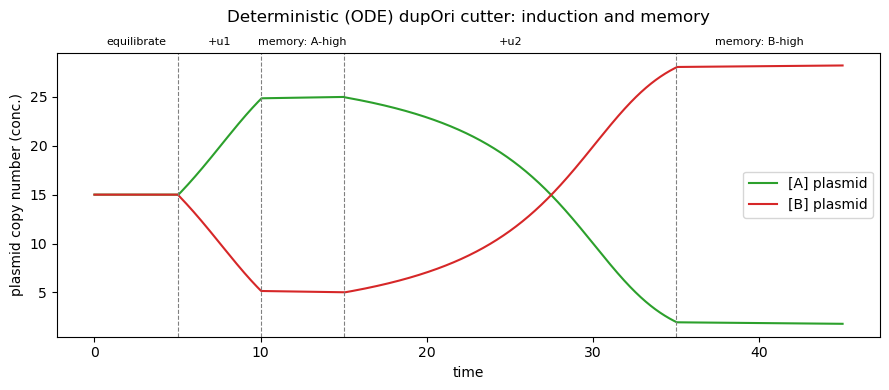

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_ode["time"], df_ode["A"], color="tab:green", label="[A] plasmid")
ax.plot(df_ode["time"], df_ode["B"], color="tab:red",   label="[B] plasmid")

trans = ax.get_xaxis_transform()
for boundary in phase_bounds[1:-1]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.8)
for label, start, end in zip(phase_labels, phase_bounds[:-1], phase_bounds[1:]):
    ax.text((start+end)/2, 1.02, label, ha="center", va="bottom", fontsize=8, transform=trans)

ax.set_xlabel("time")
ax.set_ylabel("plasmid copy number (conc.)")
ax.set_title("Deterministic (ODE) dupOri cutter: induction and memory", pad=22)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()

## 3. Hysteresis in the (A, B) phase plane

Plotting the same trajectory in `(A, B)` space rather than against time
makes the bistability concrete: the two "memory" phases sit at different
corners of the plane even though both have identical environments.
The inducer history — not the current inducer level — determines where
the system sits. That's memory.

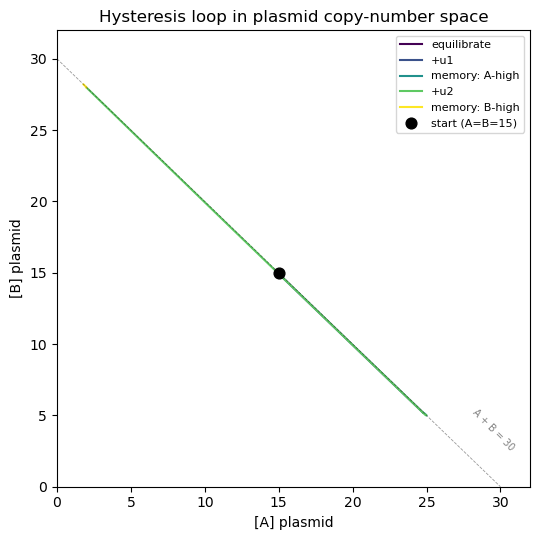

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(phase_labels)))

for label, start, end, color in zip(phase_labels, phase_bounds[:-1], phase_bounds[1:], colors):
    seg = df_ode[(df_ode["time"] >= start) & (df_ode["time"] <= end)]
    ax.plot(seg["A"], seg["B"], color=color, linewidth=1.5, label=label)

ax.scatter(df_ode["A"].iloc[0], df_ode["B"].iloc[0],
           color="black", zorder=5, s=60, label="start (A=B=15)")

ax.plot([0, 30], [30, 0], "k--", linewidth=0.6, alpha=0.4)
ax.text(28, 2.5, "A + B = 30", fontsize=7, color="0.5", rotation=-45)
ax.set_xlim(0, 32); ax.set_ylim(0, 32)
ax.set_xlabel("[A] plasmid"); ax.set_ylabel("[B] plasmid")
ax.set_title("Hysteresis loop in plasmid copy-number space")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

## 4. Stochastic switching and memory (Gillespie SSA)

The same protocol, but `simulation_method="SSA"` runs exact Gillespie
stochastic simulation with discrete plasmid copy numbers (`low_copy=True`).
The cell is given a length of 8.0 so molecule counts are large enough for
the switch to flip reliably while still showing stochastic noise against
the deterministic trajectory from section 2.

In [6]:
cell_ssa = Cell(
    id=0, position=[25.0, 25.0], orientation=[1.0, 0.0], length=8.0,
    network=ReactionNetwork("dupOri_cutter", dupOri_reactions, simulation_method="SSA"),
    growth_rate=0.0, rng=np.random.default_rng(42),
)
cell_ssa.set_concentration("A", 15.0, low_copy=True)
cell_ssa.set_concentration("B", 15.0, low_copy=True)

colony_ssa = Colony([cell_ssa], no_inducer)
sim_ssa = Simulation(colony_ssa, dt=0.02, t_max=phase_duration)

df_ssa = sim_ssa.run(t_max=1*phase_duration, show_progress=False)   # equilibrate
colony_ssa.switch_environment(add_u1)
df_ssa = sim_ssa.run(t_max=2*phase_duration, show_progress=False)   # +u1
colony_ssa.switch_environment(no_inducer)
df_ssa = sim_ssa.run(t_max=3*phase_duration, show_progress=False)   # memory
colony_ssa.switch_environment(add_u2)
df_ssa = sim_ssa.run(t_max=7*phase_duration, show_progress=False)   # +u2 (longer)
colony_ssa.switch_environment(no_inducer)
df_ssa = sim_ssa.run(t_max=9*phase_duration, show_progress=False)   # memory

print(f"cell volume: {cell_ssa.compute_volume():.2f} um^3")

cell volume: 6.81 um^3


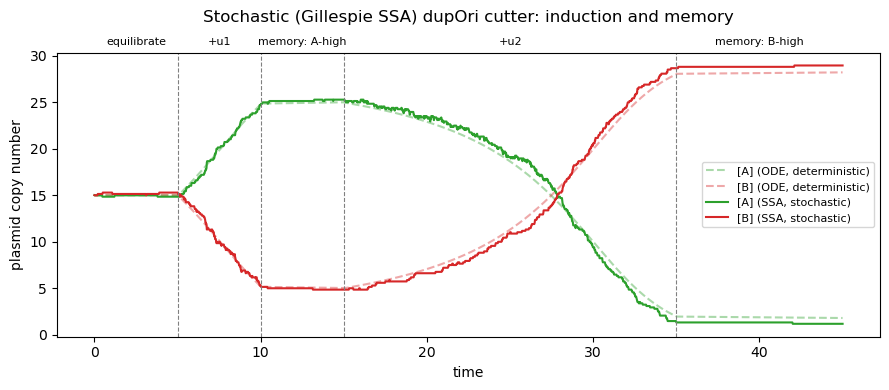

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_ode["time"], df_ode["A"], "--", color="tab:green", alpha=0.4, label="[A] (ODE, deterministic)")
ax.plot(df_ode["time"], df_ode["B"], "--", color="tab:red",   alpha=0.4, label="[B] (ODE, deterministic)")
ax.plot(df_ssa["time"], df_ssa["A"],       color="tab:green",             label="[A] (SSA, stochastic)")
ax.plot(df_ssa["time"], df_ssa["B"],       color="tab:red",               label="[B] (SSA, stochastic)")

trans = ax.get_xaxis_transform()
for boundary in phase_bounds[1:-1]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.8)
for label, start, end in zip(phase_labels, phase_bounds[:-1], phase_bounds[1:]):
    ax.text((start+end)/2, 1.02, label, ha="center", va="bottom", fontsize=8, transform=trans)

ax.set_xlabel("time")
ax.set_ylabel("plasmid copy number")
ax.set_title("Stochastic (Gillespie SSA) dupOri cutter: induction and memory", pad=22)
ax.legend(loc="center right", fontsize=8)
fig.tight_layout()
plt.show()

## 5. A growing, dividing colony: animating the switch

The same circuit in a small *growing* colony — cells divide as the
animation plays. Growth dilution acts like extra degradation on plasmid
concentrations, but logistic replication refills the capacity, so
bistability is preserved at low growth rates (`growth_rate=0.04`,
doubling time ≈ 17 time units). At each division, plasmid copies are
distributed between daughters by binomial partitioning (`low_copy=True`)
rather than the equal-concentration approximation — appropriate because
30 copies is well below the threshold where equal splitting becomes
accurate. Cells are colored by **plasmid A → green** and **plasmid B →
red** via `visualize()`, so the whole colony shifts from yellow (balanced)
to green (A-dominant) after +u1, holds green in memory, then shifts red
(B-dominant) after +u2, and holds red in memory.

In [8]:
video_shape, video_bounds = (10, 10), (50.0, 50.0)
video_phase_duration = 5.0

def make_video_env(u1=0.0, u2=0.0):
    return Environment(
        shape=video_shape, bounds=video_bounds,
        fields=[
            Field("u1", np.full(video_shape, u1), is_chemical=True),
            Field("u2", np.full(video_shape, u2), is_chemical=True),
        ],
    )

video_no_inducer = make_video_env()
video_add_u1 = make_video_env(u1=5.0)
video_add_u2 = make_video_env(u2=5.0)

video_cells = [
    Cell(
        id=i, position=position, orientation=[1.0, 0.0], length=2.0,
        network=ReactionNetwork("dupOri_cutter", dupOri_reactions),
        growth_rate=0.04, rng=np.random.default_rng(i),
    )
    for i, position in enumerate([[20.0, 25.0], [30.0, 25.0]])
]
for c in video_cells:
    c.set_concentration("A", 15.0, low_copy=True)
    c.set_concentration("B", 15.0, low_copy=True)

colony_video = Colony(video_cells, video_no_inducer, k=10.0, drag=1.0)
sim_video = Simulation(colony_video, dt=0.05, t_max=video_phase_duration)

df_video = sim_video.run(t_max=1*video_phase_duration, show_progress=False)   # equilibrate
colony_video.switch_environment(video_add_u1)
df_video = sim_video.run(t_max=2*video_phase_duration, show_progress=False)   # +u1
colony_video.switch_environment(video_no_inducer)
df_video = sim_video.run(t_max=3*video_phase_duration, show_progress=False)   # memory: A-high
colony_video.switch_environment(video_add_u2)
df_video = sim_video.run(t_max=7*video_phase_duration, show_progress=False)   # +u2 (longer)
colony_video.switch_environment(video_no_inducer)
df_video = sim_video.run(t_max=9*video_phase_duration, show_progress=False)   # memory: B-high

final = df_video[df_video["time"] == df_video["time"].max()]
print(f"colony grew from {len(video_cells)} to {int(final['alive'].sum())} living cells")

colony grew from 2 to 16 living cells


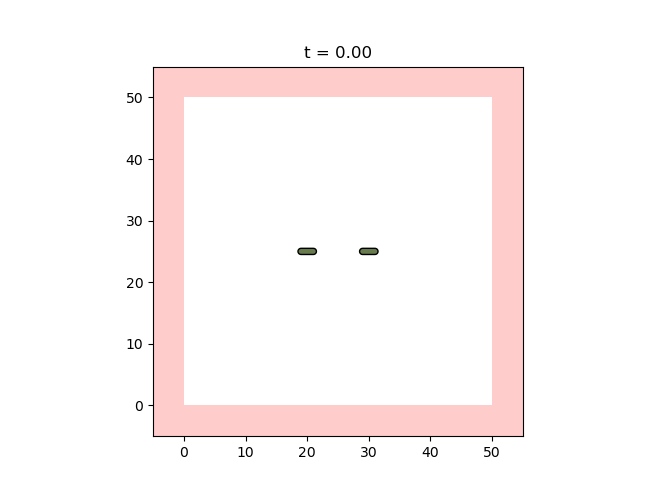

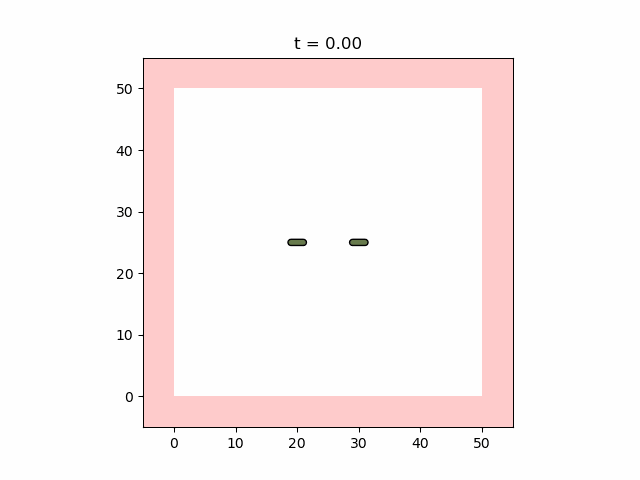

In [9]:
visualize(sim_video, red="B", green="A", stride=8, interval=80,
          save_path="outputs", filename="dupOri_cutter.gif", show_progress=False)
Image(filename="outputs/dupOri_cutter.gif")